Disease prediction using machine learning is used in healthcare to provide accurate and early diagnosis based on patient symptoms. We can build predictive models that identify diseases efficiently. In this article, we will explore the end-to-end implementation of such a system.

# Import Libraries

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import mode
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Reading the dataset

In [4]:
df=pd.read_csv('improved_disease_dataset.csv')

In [6]:
df

,fever,headache,nausea,vomiting,fatigue,joint_pain,skin_rash,cough,weight_loss,yellow_eyes,disease
0,1,0,1,0,1,0,0,1,1,0,Paralysis (brain hemorrhage)
1,0,0,1,0,0,0,1,1,0,0,Paralysis (brain hemorrhage)
2,0,0,1,0,1,0,1,1,0,0,Paralysis (brain hemorrhage)
3,0,0,1,1,1,0,1,1,1,1,Paralysis (brain hemorrhage)
4,1,0,1,0,1,0,0,0,1,1,Paralysis (brain hemorrhage)
...,...,...,...,...,...,...,...,...,...,...,...
1995,1,1,0,0,1,0,0,0,1,1,Alcoholic hepatitis
1996,1,0,0,0,1,1,1,0,1,1,Alcoholic hepatitis
1997,1,0,0,1,0,0,0,0,0,1,Alcoholic hepatitis
1998,0,0,0,0,1,1,0,0,0,1,Alcoholic hepatitis


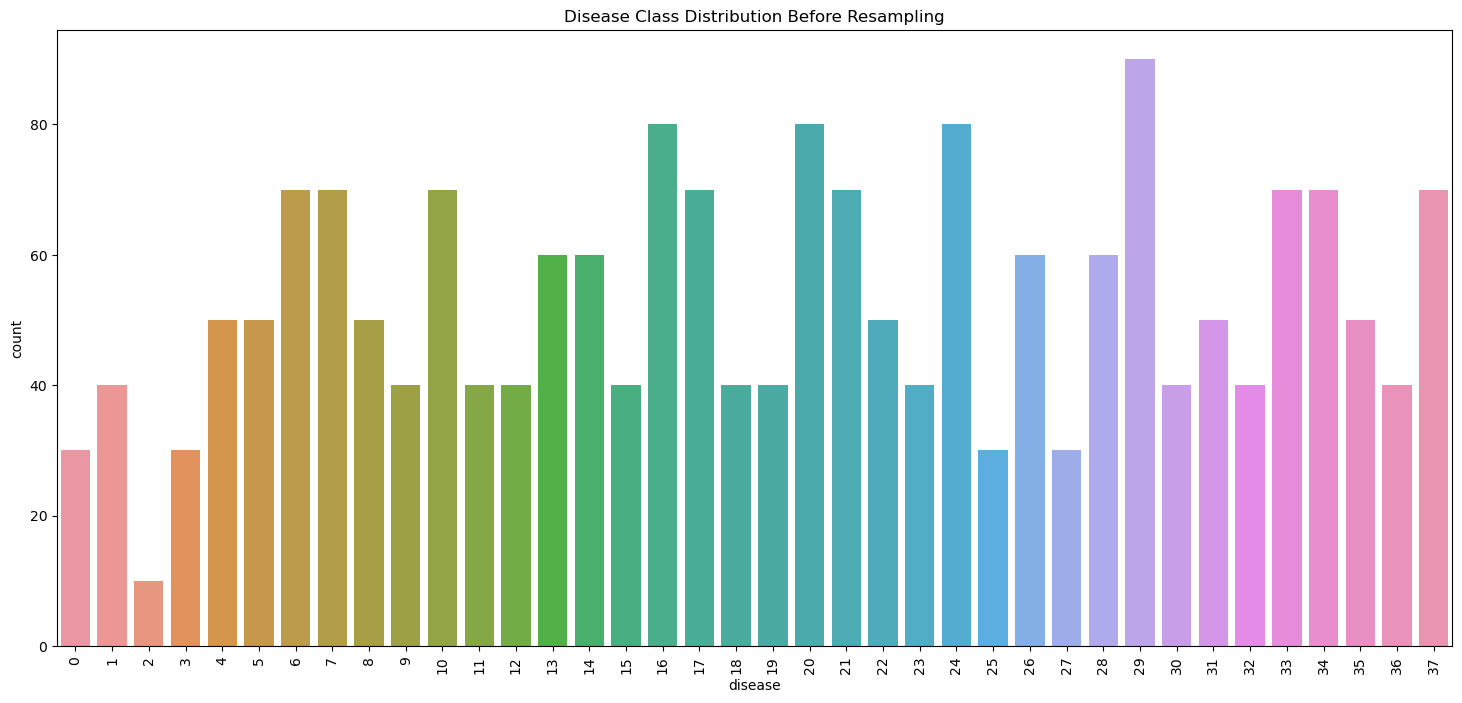

Resampled Class Distribution:
 disease
29    90
11    90
4     90
18    90
23    90
1     90
12    90
30    90
32    90
9     90
20    90
36    90
15    90
19    90
27    90
3     90
25    90
0     90
5     90
22    90
35    90
31    90
16    90
24    90
7     90
17    90
34    90
10    90
37    90
6     90
33    90
21    90
26    90
13    90
28    90
14    90
8     90
2     90
Name: count, dtype: int64


In [8]:
encoder = LabelEncoder()                       #LabelEncoder() from sklearn.preprocessing is used to convert categorical labels (like disease names) into numerical labels (e.g., "flu" → 0, "cancer" → 1, etc.).
df["disease"] = encoder.fit_transform(df["disease"]) #fit_transform both fits the encoder and transforms the "disease" column.

X = df.iloc[:, :-1]                            #X contains all columns except the last one (presumably the disease label).
y = df.iloc[:, -1]                             #y contains the last column, i.e., the target variable (disease class).

plt.figure(figsize=(18, 8))
sns.countplot(x=y)                             #Creates a bar chart showing how many samples exist per disease class before any resampling.
plt.title("Disease Class Distribution Before Resampling")
plt.xticks(rotation=90)
plt.show()

ros = RandomOverSampler(random_state=42)         #RandomOverSampler from imblearn.over_sampling is used to balance the dataset by randomly duplicating samples from underrepresented classes until all classes have the same number of samples.
X_resampled, y_resampled = ros.fit_resample(X, y) #It resamples the feature matrix X and label vector y into balanced versions: X_resampled and y_resampled.


print("Resampled Class Distribution:\n", pd.Series(y_resampled).value_counts())

Every disease class now has exactly 90 samples. Originally, dataset likely had an imbalanced distribution (some diseases had many more samples than others). After Applying Random Oversampling, which duplicated samples from underrepresented classes so that all classes are equally represented. This helps prevent the model from being biased toward majority classes during training.

Before resampling: A model might just learn to always predict the majority class (e.g., flu) because it dominates the dataset.

After resampling: The model gets an equal chance to learn from every disease class, improving its ability to generalize and detect rare diseases.

# Cross-Validation with Stratified K-Fold

In [10]:

X_resampled = X_resampled.fillna(0)

if len(y_resampled.shape) > 1:
    y_resampled = y_resampled.values.ravel()

models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(kernel='linear')  # Use linear kernel for speed
}

cv_scoring = 'accuracy'  # you can also use 'f1_weighted', 'roc_auc_ovr' for multi-class
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    try:
        scores = cross_val_score(
            model,
            X_resampled,
            y_resampled,
            cv=stratified_kfold,
            scoring=cv_scoring,
            n_jobs=-1,
            error_score='raise' 
        )
        print("=" * 50)
        print(f"Model: {model_name}")
        print(f"Scores: {scores}")
        print(f"Mean Accuracy: {scores.mean():.4f}")
    except Exception as e:
        print("=" * 50)
        print(f"Model: {model_name} failed with error:")
        print(e)

Model: Decision Tree
Scores: [0.5497076  0.54385965 0.5380117  0.53654971 0.52631579]
Mean Accuracy: 0.5389
Model: Random Forest
Scores: [0.55847953 0.54385965 0.5497076  0.53508772 0.52631579]
Mean Accuracy: 0.5427
Model: SVM
Scores: [0.48538012 0.47660819 0.45614035 0.4254386  0.47368421]
Mean Accuracy: 0.4635


# Training Individual Models and Generating Confusion Matrices

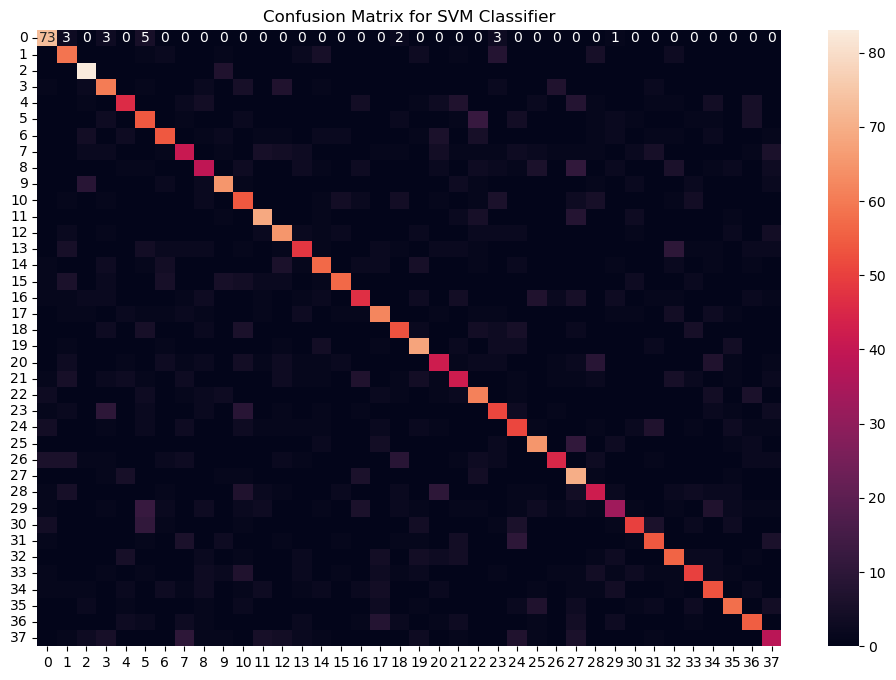

SVM Accuracy: 60.53%


In [11]:
svm_model = SVC() #support vector classifier
svm_model.fit(X_resampled, y_resampled)
svm_preds = svm_model.predict(X_resampled)

cf_matrix_svm = confusion_matrix(y_resampled, svm_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cf_matrix_svm, annot=True, fmt="d")
plt.title("Confusion Matrix for SVM Classifier")
plt.show()

print(f"SVM Accuracy: {accuracy_score(y_resampled, svm_preds) * 100:.2f}%")

The matrix shows good accuracy with most values along the diagonal meaning the SVM model predicted the correct class most of the time.

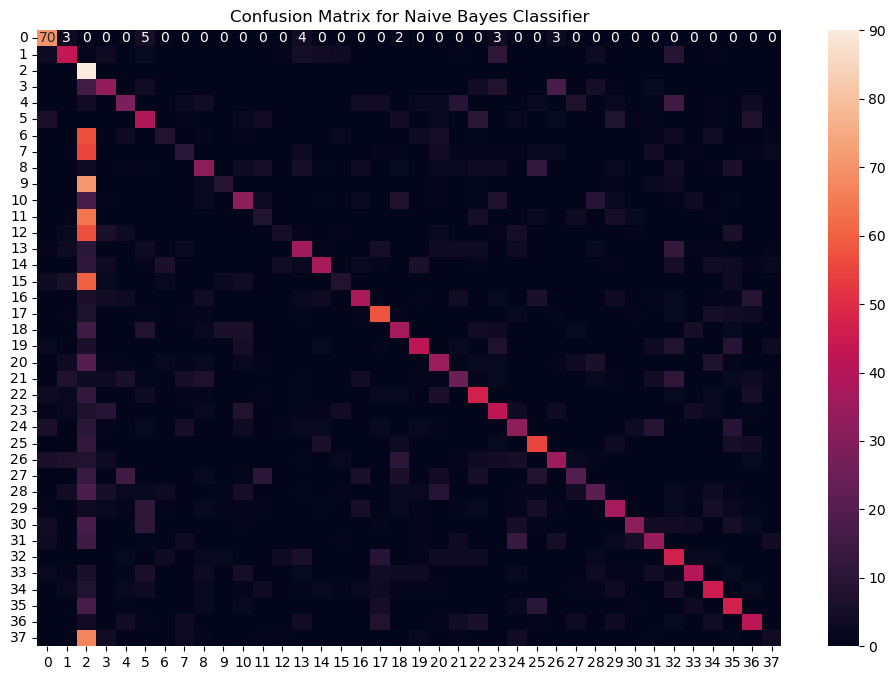

Naive Bayes Accuracy: 37.98%


In [14]:
nb_model = GaussianNB() #Gaussian Naive Bayes
nb_model.fit(X_resampled, y_resampled)
nb_preds = nb_model.predict(X_resampled)

cf_matrix_nb = confusion_matrix(y_resampled, nb_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cf_matrix_nb, annot=True, fmt="d")
plt.title("Confusion Matrix for Naive Bayes Classifier")
plt.show()

print(f"Naive Bayes Accuracy: {accuracy_score(y_resampled, nb_preds) * 100:.2f}%")

This matrix shows many off-diagonal values meaning the Naive Bayes model made more errors compared to the SVM. The predictions are less accurate and more spread out across incorrect classes.

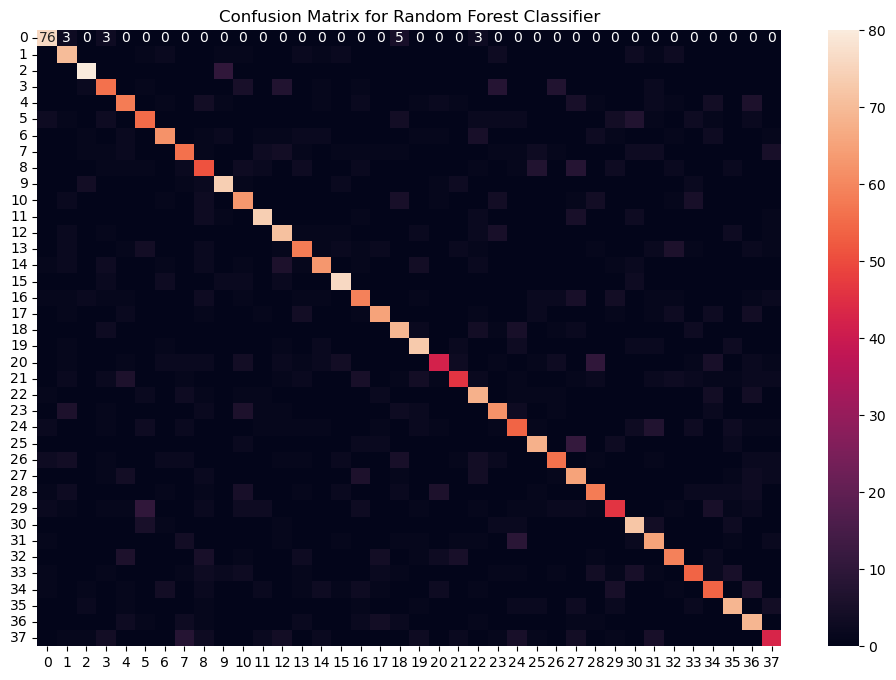

Random Forest Accuracy: 68.98%


In [16]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_resampled, y_resampled)
rf_preds = rf_model.predict(X_resampled)

cf_matrix_rf = confusion_matrix(y_resampled, rf_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cf_matrix_rf, annot=True, fmt="d")
plt.title("Confusion Matrix for Random Forest Classifier")
plt.show()

print(f"Random Forest Accuracy: {accuracy_score(y_resampled, rf_preds) * 100:.2f}%")

This confusion matrix shows strong performance with most predictions correctly placed along the diagonal. It has fewer misclassifications than Naive Bayes and is comparable or slightly better than SVM.

# Combining Predictions for Robustness

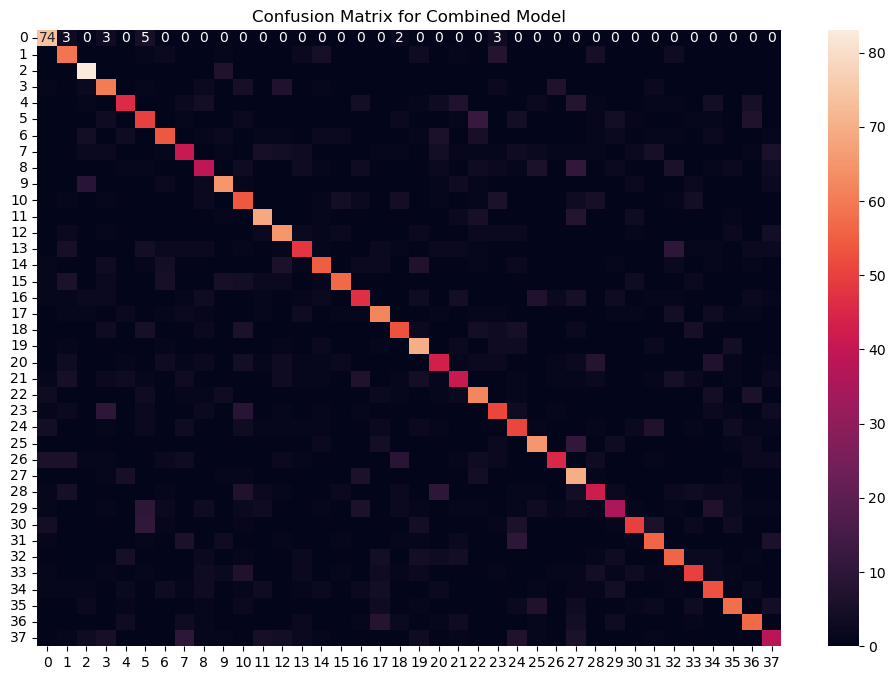

Combined Model Accuracy: 60.64%


In [18]:
from statistics import mode

final_preds = [mode([i, j, k]) for i, j, k in zip(svm_preds, nb_preds, rf_preds)]

cf_matrix_combined = confusion_matrix(y_resampled, final_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cf_matrix_combined, annot=True, fmt="d")
plt.title("Confusion Matrix for Combined Model")
plt.show()

print(f"Combined Model Accuracy: {accuracy_score(y_resampled, final_preds) * 100:.2f}%")

Each cell shows how many times a true class (rows) was predicted as another class (columns) with high values on the diagonal indicating correct predictions.

# Creating Prediction Function

In [20]:
symptoms = X.columns.values
symptom_index = {symptom: idx for idx, symptom in enumerate(symptoms)}

def predict_disease(input_symptoms):
    input_symptoms = input_symptoms.split(",")
    input_data = [0] * len(symptom_index)
    
    for symptom in input_symptoms:
        if symptom in symptom_index:
            input_data[symptom_index[symptom]] = 1
    
    input_data = np.array(input_data).reshape(1, -1)

    rf_pred = encoder.classes_[rf_model.predict(input_data)[0]]
    nb_pred = encoder.classes_[nb_model.predict(input_data)[0]]
    svm_pred = encoder.classes_[svm_model.predict(input_data)[0]]

    final_pred = mode([rf_pred, nb_pred, svm_pred])
    
    return {
        "Random Forest Prediction": rf_pred,
        "Naive Bayes Prediction": nb_pred,
        "SVM Prediction": svm_pred,
        "Final Prediction": final_pred
    }

print(predict_disease("Itching,Skin Rash,Nodal Skin Eruptions"))

{'Random Forest Prediction': 'Heart attack', 'Naive Bayes Prediction': 'Urinary tract infection', 'SVM Prediction': 'Impetigo', 'Final Prediction': 'Heart attack'}


C:\Users\jadha\AppData\anaconda\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\jadha\AppData\anaconda\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
C:\Users\jadha\AppData\anaconda\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


The output shows predictions from three classifiers where Random Forest predicted “Heart Attack”, Naive Bayes Predicted “Urinary tract Infection” and SVM predict “Impetigo”. The final combined prediction was “Heart Attack”. We can further fine tune this model to make predictions more accurate.